In [51]:
# ── Global paths ──────────────────────────────────────────────────────────────
SWEAT_0 = "../20260404-experiment/sweat.csv"   # Defective — NH3 pin disconnected (miswired from start)
SWEAT_1 = "../20260405-experiment/sweat.csv"   # Reference — clean wiring
SWEAT_2 = "../20260331-experiment/sweat.csv"
BLOOD_0 = "../20260406-experiment/1.5_blood.csv"
BLOOD_1 = "../20260406-experiment/1.5_blood_2.csv"

MEMS = ["voc", "nh3", "hcho"]

# Smoothing params
ROLLING_WINDOW = 20   # samples (= seconds at 1 Hz)
SG_WINDOW      = 31   # Savitzky-Golay window (must be odd)
SG_POLY        = 3    # Savitzky-Golay polynomial order

# SWEAT_0 defect: NH3 zero runs (rows where NH3 = 0.0 V)
SWEAT_0_DEFECT_ZERO_RUNS = [(3912, 3983), (4012, 4036)]  # (start_row, end_row)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

def load(path, t_min=1500, t_max=None):
    df = pd.read_csv(path, parse_dates=["wall_time"])
    df["elapsed_s"] = (df["wall_time"] - df["wall_time"].iloc[0]).dt.total_seconds()
    for col in MEMS:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df[df["elapsed_s"] >= t_min]
    if t_max is not None:
        df = df[df["elapsed_s"] < t_max]
    return df.reset_index(drop=True)

sweat_0  = load(SWEAT_0, t_max=4000)
sweat_1  = load(SWEAT_1)                                 # full — for initial visualization
sweat_1a = load(SWEAT_1, t_max=3900)                     # first sweat sample
sweat_1b = load(SWEAT_1, t_min=3900)                     # second sweat sample
sweat_1b = sweat_1b.assign(                              # reset elapsed to start from 0
    elapsed_s=sweat_1b["elapsed_s"] - sweat_1b["elapsed_s"].iloc[0]
)
sweat_1b = sweat_1b[sweat_1b["elapsed_s"] >= 200].reset_index(drop=True)  # trim stabilization
sweat_2  = load(SWEAT_2)
blood_0  = load(BLOOD_0)
blood_1  = load(BLOOD_1, t_min=1750)                     # trim stabilization

print({
    "sweat_0":  len(sweat_0),
    "sweat_1":  len(sweat_1),
    "sweat_1a": len(sweat_1a),
    "sweat_1b": len(sweat_1b),
    "sweat_2":  len(sweat_2),
    "blood_0":  len(blood_0),
    "blood_1":  len(blood_1),
})


## SWEAT_0 Defect Investigation

**Problem:** The NH3 sensor wire was miswired to the VOC ADC pin from the beginning of the session — not during recording.

**Effect on NH3:** Pin 34 (NH3) was floating/unconnected → reads `0.0 V` for large blocks of the session.

**Effect on VOC:** The NH3 wire loading pin 35 (VOC) might suppress the VOC readings.

**Conclusion:** SWEAT_0 VOC and NH3 channels are both unreliable and should not be used for model training.


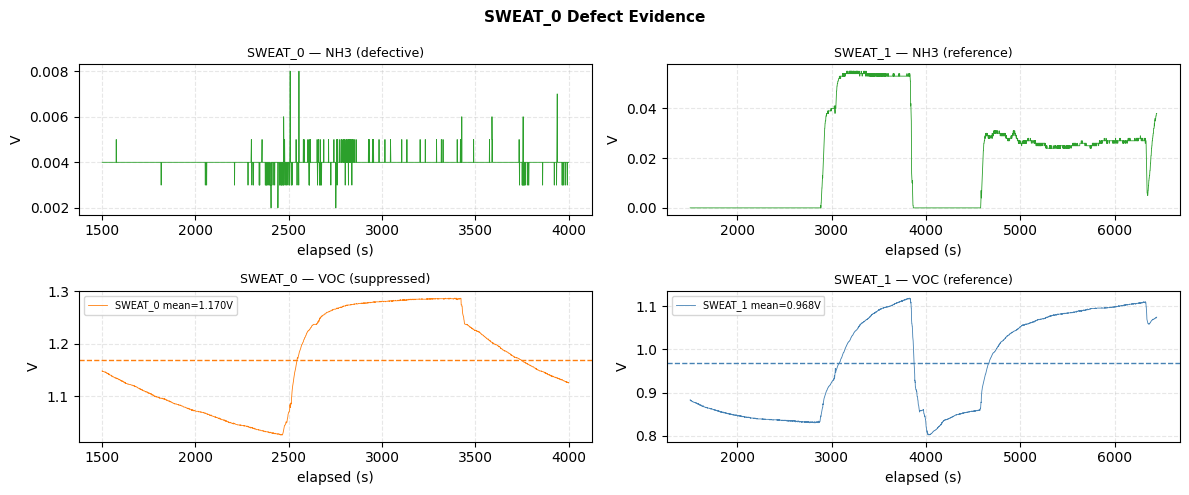

NH3 zeros in SWEAT_0: 0/2412 (0.0%)
VOC mean — SWEAT_0: 1.170 V   SWEAT_1: 0.968 V  (diff: -0.201 V)


In [53]:
fig, axes = plt.subplots(2, 2, figsize=(12, 5))
fig.suptitle("SWEAT_0 Defect Evidence", fontsize=11, fontweight="bold")

# Detect zero-run time spans directly from the trimmed dataframe
def zero_time_spans(df, col):
    is_zero = (df[col] == 0.0)
    spans = []
    in_run = False
    for i, val in enumerate(is_zero):
        if val and not in_run:
            in_run = True
            t_start = df["elapsed_s"].iloc[i]
        elif not val and in_run:
            in_run = False
            spans.append((t_start, df["elapsed_s"].iloc[i - 1]))
    if in_run:
        spans.append((t_start, df["elapsed_s"].iloc[-1]))
    return spans

# NH3: stuck-at-zero blocks (defective)
ax = axes[0, 0]
ax.plot(sweat_0["elapsed_s"], sweat_0["nh3"], color="tab:green", linewidth=0.6)
for t0, t1 in zero_time_spans(sweat_0, "nh3"):
    ax.axvspan(t0, t1, color="red", alpha=0.2, label="stuck at 0 V")
ax.set_title("SWEAT_0 — NH3 (defective)", fontsize=9)
ax.set_ylabel("V"); ax.set_xlabel("elapsed (s)")
ax.grid(True, alpha=0.3, linestyle="--")
handles, labels = ax.get_legend_handles_labels()
if handles:
    ax.legend(handles[:1], labels[:1], fontsize=7)

# NH3 reference (full signal)
ax = axes[0, 1]
ax.plot(sweat_1["elapsed_s"], sweat_1["nh3"], color="tab:green", linewidth=0.6)
ax.set_title("SWEAT_1 — NH3 (reference)", fontsize=9)
ax.set_ylabel("V"); ax.set_xlabel("elapsed (s)")
ax.grid(True, alpha=0.3, linestyle="--")

# VOC defective
ax = axes[1, 0]
ax.plot(sweat_0["elapsed_s"], sweat_0["voc"], color="tab:orange", linewidth=0.6, label=f"SWEAT_0 mean={sweat_0['voc'].mean():.3f}V")
ax.axhline(sweat_0["voc"].mean(), color="tab:orange", linestyle="--", linewidth=1)
ax.set_title("SWEAT_0 — VOC (suppressed)", fontsize=9)
ax.set_ylabel("V"); ax.set_xlabel("elapsed (s)")
ax.legend(fontsize=7); ax.grid(True, alpha=0.3, linestyle="--")

# VOC reference
ax = axes[1, 1]
ax.plot(sweat_1["elapsed_s"], sweat_1["voc"], color="steelblue", linewidth=0.6, label=f"SWEAT_1 mean={sweat_1['voc'].mean():.3f}V")
ax.axhline(sweat_1["voc"].mean(), color="steelblue", linestyle="--", linewidth=1)
ax.set_title("SWEAT_1 — VOC (reference)", fontsize=9)
ax.set_ylabel("V"); ax.set_xlabel("elapsed (s)")
ax.legend(fontsize=7); ax.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

nh3_zeros = (sweat_0["nh3"] == 0.0).sum()
print(f"NH3 zeros in SWEAT_0: {nh3_zeros}/{len(sweat_0)} ({100*nh3_zeros/len(sweat_0):.1f}%)")
print(f"VOC mean — SWEAT_0: {sweat_0['voc'].mean():.3f} V   SWEAT_1: {sweat_1['voc'].mean():.3f} V  (diff: {sweat_1['voc'].mean()-sweat_0['voc'].mean():.3f} V)")


## Initial Visualization

Raw signal with rolling average and Savitzky-Golay smoothing overlaid.
SWEAT_0 is included for completeness but its VOC/NH3 channels are defective (see above).


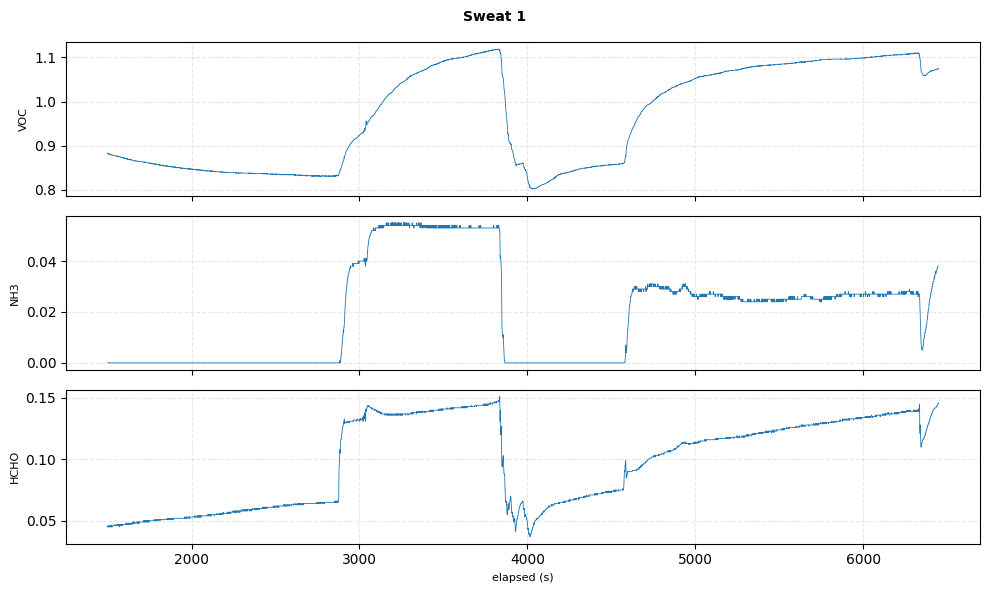

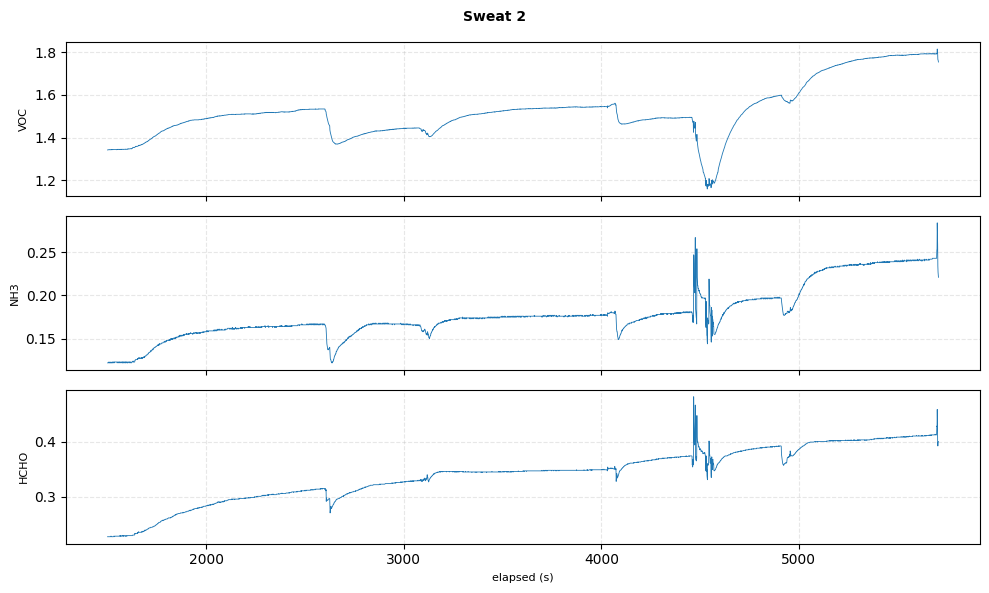

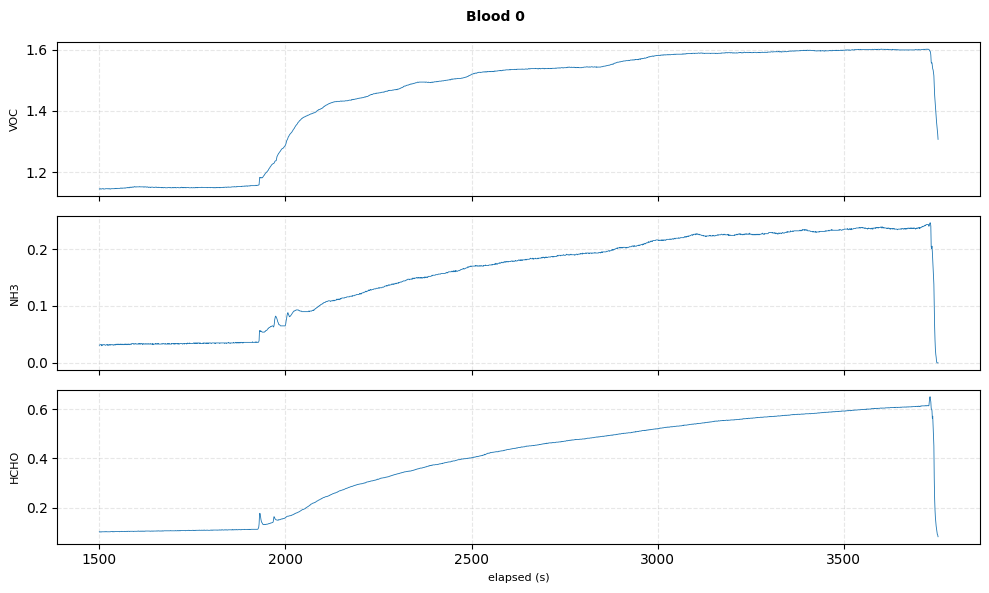

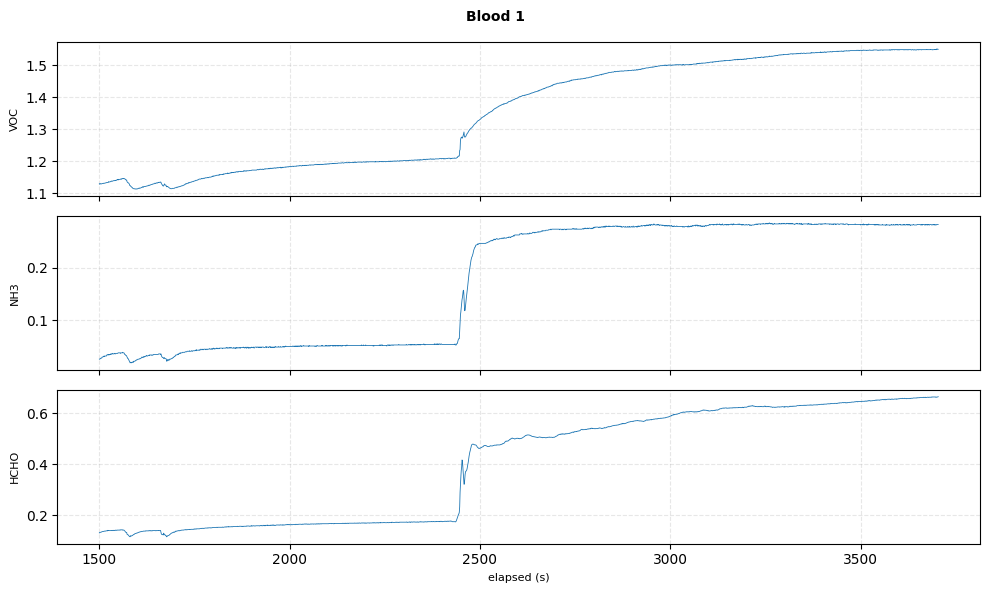

In [54]:
datasets = {
    "Sweat 1":  sweat_1,
    "Sweat 2":  sweat_2,
    "Blood 0":  blood_0,
    "Blood 1":  blood_1,
}

def plot_raw(name, df):
    fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
    fig.suptitle(name, fontsize=10, fontweight="bold")

    for ax, col in zip(axes, MEMS):
        ax.plot(df["elapsed_s"], df[col], linewidth=0.6)
        ax.set_ylabel(col.upper(), fontsize=8)
        ax.grid(True, alpha=0.3, linestyle="--")

    axes[-1].set_xlabel("elapsed (s)", fontsize=8)
    plt.tight_layout()
    plt.show()

for name, df in datasets.items():
    plot_raw(name, df)


## Filtered Visualization

Datasets in scope: **SWEAT_1a, SWEAT_1b, BLOOD_0, BLOOD_1**. SWEAT_0 and SWEAT_2 excluded for now.

All channels use a **causal EMA filter** (real-time compatible — no future data used).

| Dataset | Trimming | VOC | NH3 | HCHO |
|---------|----------|-----|-----|------|
| SWEAT_1a | 1500s – 3900s | EMA span=30, artifact patch 2800–3050s | EMA span=30, artifact patch 2800–3050s | EMA span=30, artifact patch 2800–3050s |
| SWEAT_1b | 3900s+ (reset), discard first 200s | EMA span=30 | EMA span=80 (noisy) | EMA span=30, artifact patch 700–1050s |
| BLOOD_0 | 1500s+ | EMA span=30 | EMA span=30, interpolate isolated zeros | EMA span=30 |
| BLOOD_1 | 1750s+ | EMA span=30 | EMA span=30 | EMA span=30 |


In [59]:
# ── Per-dataset filter config ─────────────────────────────────────────────────
# span: default EMA span (samples ≈ seconds at 1 Hz)
# span_override: {col: span} — per-channel span override
# interpolate_cols: columns where isolated zeros are interpolated before filtering
# artifact_windows: {col: [(t_start, t_end), ...]} — regions to patch via linear interp

FILTER_CONFIG = {
    "SWEAT_1a": {
        "span": 30,
        "span_override": {},
        "interpolate_cols": [],
        "artifact_windows": {
            "voc":  [(2800, 3050)],
            "nh3":  [(2800, 3050)],
            "hcho": [(2800, 3050)],
        },
    },
    "SWEAT_1b": {
        "span": 30,
        "span_override": {"nh3": 80},   # NH3 is noisy — smooth more aggressively
        "interpolate_cols": [],
        "artifact_windows": {
            "hcho": [(700, 1050)],       # clunky transition after sample introduced
        },
    },
    "BLOOD_0": {
        "span": 30,
        "span_override": {},
        "interpolate_cols": ["nh3"],
        "artifact_windows": {},
    },
    "BLOOD_1": {
        "span": 30,
        "span_override": {},
        "interpolate_cols": [],
        "artifact_windows": {},
    },
}

# ── Filter application ────────────────────────────────────────────────────────
def apply_filter(df, config):
    out = df.copy()
    for col in MEMS:
        s = out[col].copy().astype(float)

        # Interpolate isolated zeros
        if col in config.get("interpolate_cols", []):
            s[s == 0.0] = float("nan")
            s = s.interpolate(method="linear").ffill().bfill()

        # Patch artifact windows via linear interpolation (Option C)
        for t0, t1 in config.get("artifact_windows", {}).get(col, []):
            mask = (out["elapsed_s"] >= t0) & (out["elapsed_s"] <= t1)
            s[mask] = float("nan")
            s = s.interpolate(method="linear").ffill().bfill()

        # Causal EMA — per-channel span override if specified
        span = config.get("span_override", {}).get(col, config["span"])
        out[col] = s.ewm(span=span, adjust=False).mean()

    return out

filtered = {
    name: apply_filter(df, FILTER_CONFIG[name])
    for name, df in [
        ("SWEAT_1a", sweat_1a),
        ("SWEAT_1b", sweat_1b),
        ("BLOOD_0",  blood_0),
        ("BLOOD_1",  blood_1),
    ]
}


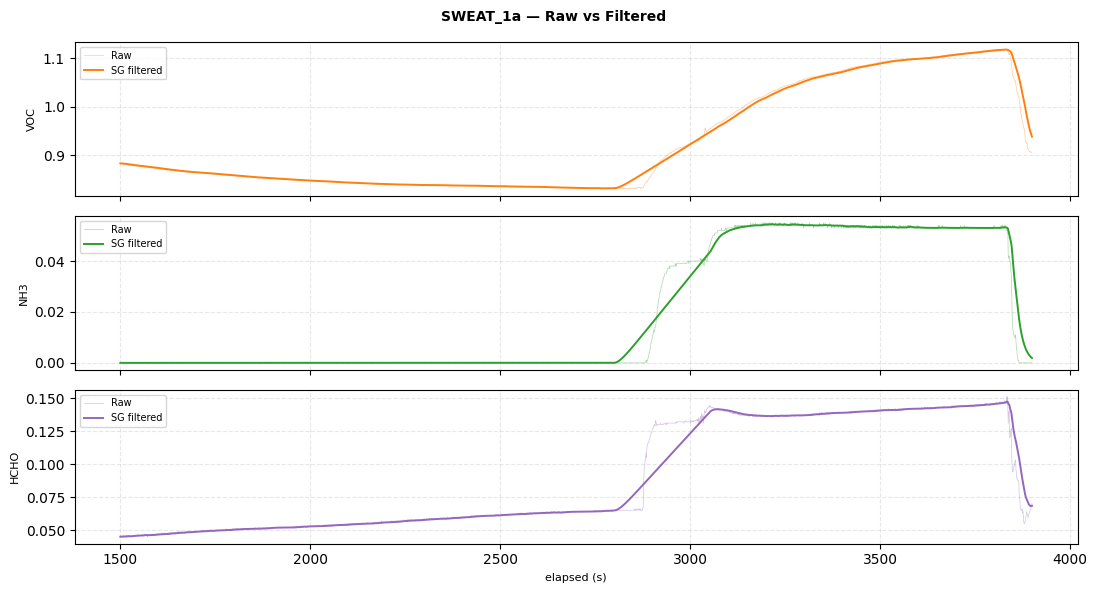

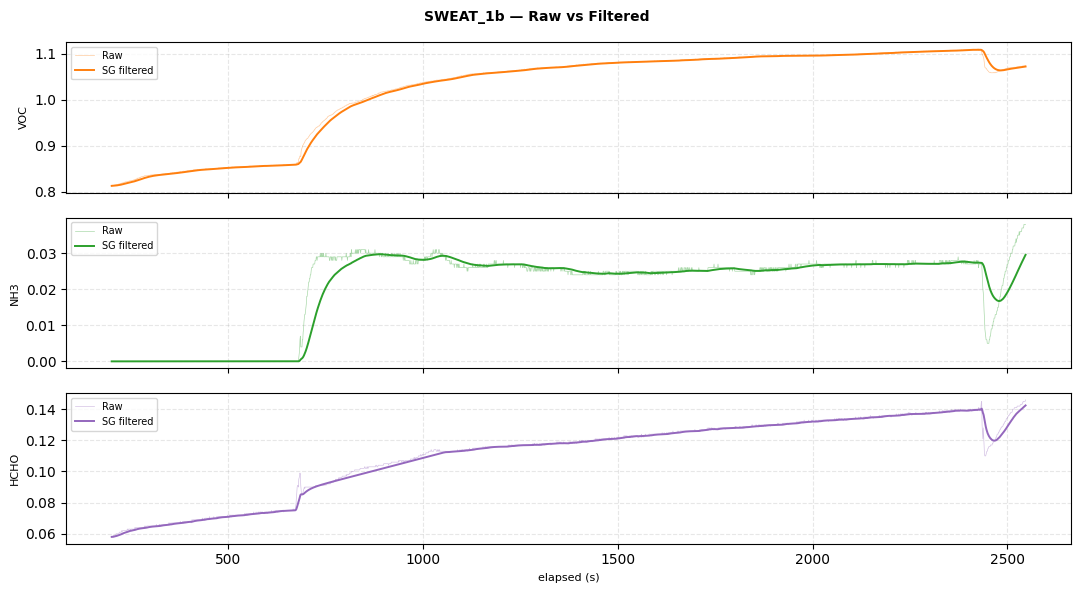

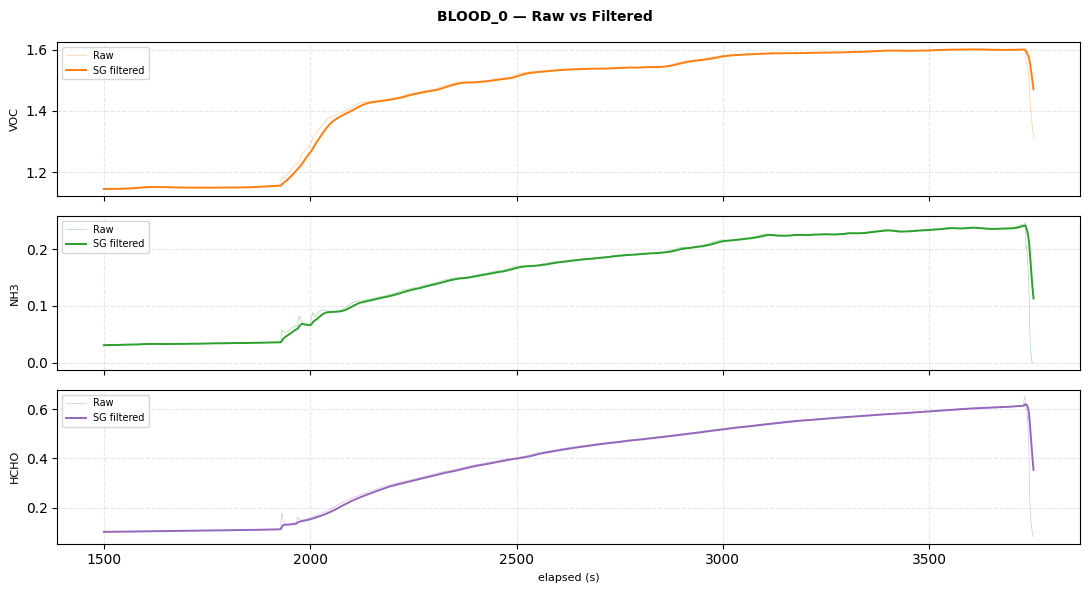

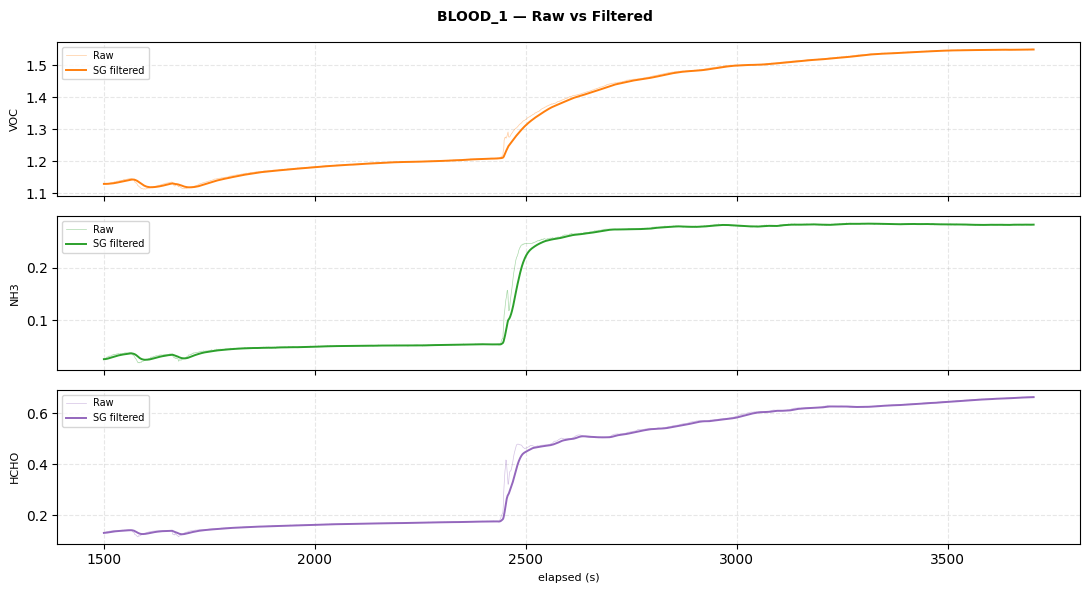

In [60]:
COLORS = {"voc": "tab:orange", "nh3": "tab:green", "hcho": "tab:purple"}

raw_map = {
    "SWEAT_1a": sweat_1a,
    "SWEAT_1b": sweat_1b,
    "BLOOD_0":  blood_0,
    "BLOOD_1":  blood_1,
}

for name, filt_df in filtered.items():
    raw_df = raw_map[name]
    fig, axes = plt.subplots(3, 1, figsize=(11, 6), sharex=True)
    fig.suptitle(f"{name} — Raw vs Filtered", fontsize=10, fontweight="bold")

    for ax, col in zip(axes, MEMS):
        color = COLORS[col]
        ax.plot(raw_df["elapsed_s"],  raw_df[col],  color=color, linewidth=0.5, alpha=0.4, label="Raw")
        ax.plot(filt_df["elapsed_s"], filt_df[col], color=color, linewidth=1.4, label="SG filtered")
        ax.set_ylabel(col.upper(), fontsize=8)
        ax.legend(fontsize=7, loc="upper left")
        ax.grid(True, alpha=0.3, linestyle="--")

    axes[-1].set_xlabel("elapsed (s)", fontsize=8)
    plt.tight_layout()
    plt.show()
